In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/hassanjameelahmed/aldrees-petroleum-and-transport-services-company/Aldrees Petroleum and Transport Services Company.csv


## Title:
Aldrees Petroleum and Transport Services Company – Fuel & Logistics Leader

## Description:
Aldrees Petroleum and Transport Services Company is a leading Saudi Arabia–based company specializing in petroleum retail, fuel distribution, and integrated transport services. Established with a strong presence across the Kingdom, the company operates an extensive network of fuel stations offering high-quality gasoline, diesel, and convenience services to both individual and commercial customers.

Beyond fuel retailing, Aldrees plays a significant role in logistics and transportation, providing efficient supply chain solutions, including tanker transportation and fleet management services. The company is known for its commitment to safety, operational excellence, and customer satisfaction, while continuously expanding its infrastructure and adopting modern technologies to enhance service delivery.

With a focus on sustainability and growth, Aldrees continues to strengthen its position as a trusted partner in the energy and transport sectors in the region.

## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/hassanjameelahmed/aldrees-petroleum-and-transport-services-company/Aldrees Petroleum and Transport Services Company.csv")

In [3]:
df.head()

,Date,Close,High,Low,Open,Volume
0,3/4/2010,6.128256,6.161028,6.062714,6.062714,528982
1,3/7/2010,6.161028,6.210185,6.128256,6.161028,883165
2,3/8/2010,6.324884,6.324884,6.144641,6.161028,1635671
3,3/9/2010,6.374043,6.390428,6.324885,6.324885,878554
4,3/10/2010,6.357657,6.374043,6.275729,6.374043,578921


In [4]:
df.tail()

,Date,Close,High,Low,Open,Volume
3906,1/25/2026,122.099998,123.300003,120.900002,122.199997,427903
3907,1/26/2026,121.599998,123.000000,121.400002,122.099998,380132
3908,1/27/2026,121.199997,122.199997,121.199997,121.599998,304631
3909,1/28/2026,121.300003,122.400002,120.000000,121.300003,653553
3910,1/29/2026,119.500000,121.300003,118.099998,121.099998,664504


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3911 entries, 0 to 3910
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3911 non-null   object 
 1   Close   3911 non-null   float64
 2   High    3911 non-null   float64
 3   Low     3911 non-null   float64
 4   Open    3911 non-null   float64
 5   Volume  3911 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 183.5+ KB


In [6]:
df.describe()

,Close,High,Low,Open,Volume
count,3911.000000,3911.000000,3911.000000,3911.000000,3.911000e+03
mean,38.232913,38.735696,37.743976,38.235270,7.064399e+05
std,40.692017,41.287848,40.112618,40.715499,9.119258e+05
min,5.456442,5.456442,5.325357,5.456442,0.000000e+00
25%,10.379870,10.449726,10.315879,10.379870,2.277010e+05
50%,16.528135,16.767876,16.242788,16.541280,4.399780e+05
75%,51.701580,52.135442,51.127715,51.701023,8.685735e+05
max,153.300003,154.100006,151.000000,153.199997,1.386675e+07


In [7]:
df.isnull().sum()

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

Date       object
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object

In [10]:
df.shape

(3911, 6)

In [11]:
df.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

In [12]:
df.nunique()

Date      3911
Close     2050
High      3415
Low       3419
Open      3533
Volume    3690
dtype: int64

## EDA

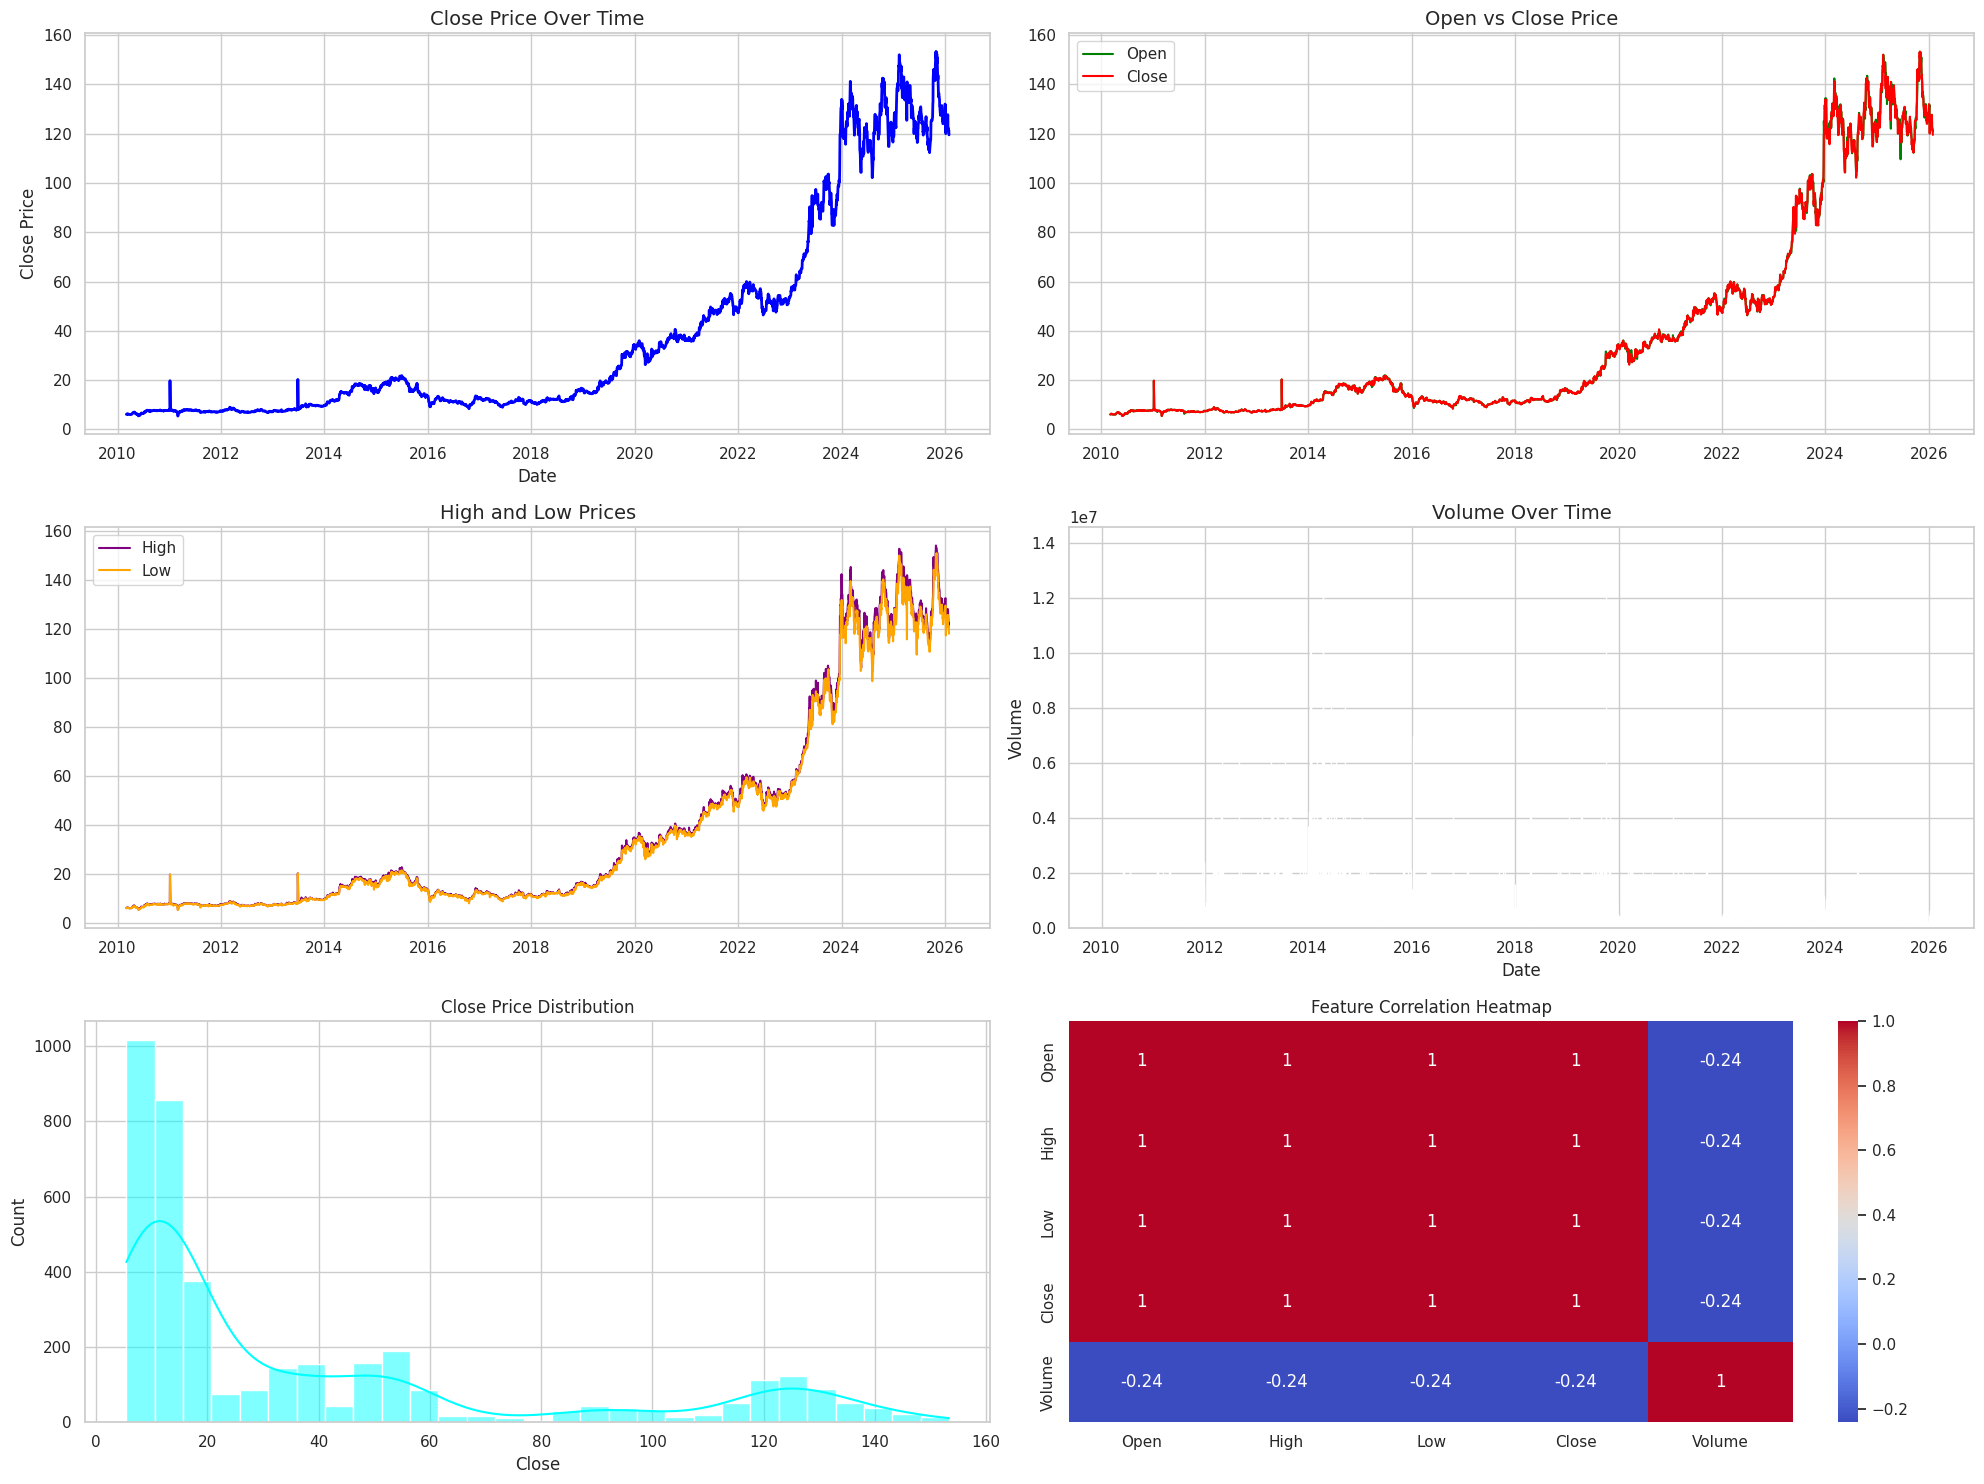

In [13]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Sort values by Date
df = df.sort_values('Date')

# =======================
# STYLE SETTINGS
# =======================
sns.set(style="whitegrid")
plt.figure(figsize=(20, 15))

# =======================
# 1. CLOSE PRICE TREND
# =======================
plt.subplot(3, 2, 1)
plt.plot(df['Date'], df['Close'], color='blue', linewidth=2)
plt.title("Close Price Over Time", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Close Price")

# =======================
# 2. OPEN vs CLOSE
# =======================
plt.subplot(3, 2, 2)
plt.plot(df['Date'], df['Open'], label='Open', color='green')
plt.plot(df['Date'], df['Close'], label='Close', color='red')
plt.title("Open vs Close Price", fontsize=14)
plt.legend()

# =======================
# 3. HIGH & LOW PRICE
# =======================
plt.subplot(3, 2, 3)
plt.plot(df['Date'], df['High'], label='High', color='purple')
plt.plot(df['Date'], df['Low'], label='Low', color='orange')
plt.title("High and Low Prices", fontsize=14)
plt.legend()

# =======================
# 4. VOLUME TREND
# =======================
plt.subplot(3, 2, 4)
plt.bar(df['Date'], df['Volume'], color='brown')
plt.title("Volume Over Time", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Volume")

# =======================
# 5. PRICE DISTRIBUTION
# =======================
plt.subplot(3, 2, 5)
sns.histplot(df['Close'], kde=True, color='cyan')
plt.title("Close Price Distribution")

# =======================
# 6. CORRELATION HEATMAP
# =======================
plt.subplot(3, 2, 6)
corr = df[['Open', 'High', 'Low', 'Close', 'Volume']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")

# =======================
# FINAL LAYOUT
# =======================
plt.tight_layout()
plt.show()


import plotly.graph_objects as go

fig = go.Figure(data=[go.Candlestick(
    x=df['Date'],
    open=df['Open'],
    high=df['High'],
    low=df['Low'],
    close=df['Close'],
    increasing_line_color='green',
    decreasing_line_color='red'
)])

fig.update_layout(title='Candlestick Chart',
                  xaxis_title='Date',
                  yaxis_title='Price')

fig.show()

===== Logistic Regression =====
Accuracy: 0.4718670076726343
              precision    recall  f1-score   support

           0       0.52      0.37      0.43       425
           1       0.44      0.59      0.51       357

    accuracy                           0.47       782
   macro avg       0.48      0.48      0.47       782
weighted avg       0.48      0.47      0.47       782


===== Random Forest =====
Accuracy: 0.551150895140665
              precision    recall  f1-score   support

           0       0.55      0.96      0.70       425
           1       0.57      0.07      0.12       357

    accuracy                           0.55       782
   macro avg       0.56      0.51      0.41       782
weighted avg       0.56      0.55      0.43       782



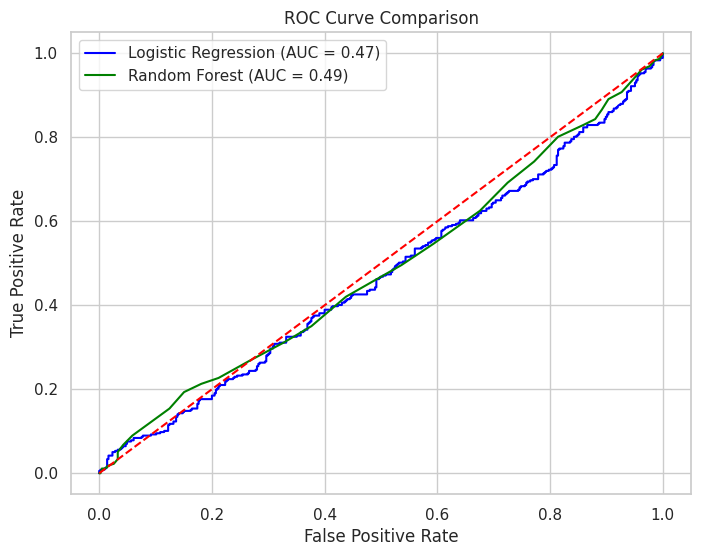

In [14]:
# ===============================
# 1. IMPORT LIBRARIES
# ===============================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Convert Date
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

# ===============================
# 3. CREATE TARGET (NO LEAKAGE)
# ===============================
# Predict: Will price go UP tomorrow?

df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)

# Drop last row (no future value)
df = df.dropna()

# ===============================
# 4. FEATURE ENGINEERING
# ===============================
df['Price_Change'] = df['Close'] - df['Open']
df['High_Low'] = df['High'] - df['Low']
df['Return'] = df['Close'].pct_change()

# Drop NA created by pct_change
df = df.dropna()

# ===============================
# 5. SELECT FEATURES
# ===============================
features = ['Open', 'High', 'Low', 'Close', 'Volume',
            'Price_Change', 'High_Low', 'Return']

X = df[features]
y = df['Target']

# ===============================
# 6. TRAIN-TEST SPLIT (TIME SERIES)
# ===============================
split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

# ===============================
# 7. SCALING (NO LEAKAGE)
# ===============================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ===============================
# 8. MODEL 1: LOGISTIC REGRESSION
# ===============================
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

# ===============================
# 9. MODEL 2: RANDOM FOREST
# ===============================
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# ===============================
# 10. EVALUATION
# ===============================
print("===== Logistic Regression =====")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

print("\n===== Random Forest =====")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

# ===============================
# 11. ROC CURVE
# ===============================
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# ===============================
# 12. PLOT ROC CURVE
# ===============================
plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_lr:.2f})', color='blue')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.2f})', color='green')

plt.plot([0,1], [0,1], linestyle='--', color='red')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

## thank you..pls upvote!!!!!!!!!1